In [1]:
# ============================================
# COMPLETE GLAUCOMA DETECTION MODEL TRAINING
# ============================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import os
import time
from collections import Counter
import json
from sklearn.metrics import classification_report


In [2]:
# Dataset paths in Google Drive
TRAIN_PATH = "dataset/train/"
TEST_PATH = "dataset/test/" 
SAVE_DIR = "glaucoma_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# Training settings
BATCH_SIZE = 32
EPOCHS = 5
LEARNING_RATE = 0.001
USE_SUBSET = False  # Set to True for faster testing with less data
SUBSET_RATIO = 0.3  # Only used if USE_SUBSET = True

print(f"\n Training Configuration:")
print(f"   Train data: {TRAIN_PATH}")
print(f"   Test data: {TEST_PATH}")
print(f"   Save location: {SAVE_DIR}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Epochs: {EPOCHS}")
print(f"   Learning rate: {LEARNING_RATE}")



 Training Configuration:
   Train data: dataset/train/
   Test data: dataset/test/
   Save location: glaucoma_models
   Batch size: 32
   Epochs: 5
   Learning rate: 0.001


In [3]:
# ============================================
# 2. LOAD AND PREPARE DATA
# ============================================

# Data transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])


In [28]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])
print("\nLoading datasets...")
train_dataset = datasets.ImageFolder(root=TRAIN_PATH, transform=train_transform)
test_dataset = datasets.ImageFolder(root=TEST_PATH, transform=test_transform)

# Get class names
class_names = train_dataset.classes
print(f"\n Classes found: {class_names}")
print(f"   Training samples: {len(train_dataset)}")
print(f"   Test samples: {len(test_dataset)}")


Loading datasets...

 Classes found: ['glaucoma', 'normal']
   Training samples: 9148
   Test samples: 669


In [5]:
# Check class distribution
train_counts = Counter([label for _, label in train_dataset])
print(f"\n Class distribution:")
for i, class_name in enumerate(class_names):
    print(f"   {class_name}: {train_counts[i]} images")

# Handle class imbalance with weights
class_weights = 1.0 / torch.tensor([train_counts[i] for i in range(len(class_names))])
class_weights = class_weights / class_weights.sum()
print(f"\n Class weights: {class_weights}")



 Class distribution:
   glaucoma: 5486 images
   normal: 3662 images

 Class weights: tensor([0.4003, 0.5997])


In [6]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


In [ ]:
# ============================================
# 3. CREATE THE MODEL (ResNet50 CNN)
# ============================================

print("\n🏗️ Building ResNet50 model...")

# Load pre-trained ResNet50
model = models.resnet50(pretrained=True)

# Freeze early layers (optional - helps with smaller datasets)
for param in model.parameters():
    param.requires_grad = False


# Unfreeze the last few layers for fine-tuning
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

# Replace the classifier for 2 classes (Glaucoma vs Normal)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, len(class_names))
)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)



🏗️ Building ResNet50 model...


C:\Users\SALIM\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\SALIM\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [9]:
print(f"   ✅ Model created successfully!")
print(f"   Device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
print(f"   Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")


   ✅ Model created successfully!
   Device: cpu
   Model parameters: 24.6M


In [10]:
# ============================================
# 4. SETUP TRAINING COMPONENTS (NO SCHEDULER)
# ============================================

# Loss function with class weights for imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Optimizer - simple Adam with fixed learning rate
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"\n Training components ready:")
print(f"   Loss function: CrossEntropyLoss with class weights")
print(f"   Optimizer: Adam (lr={LEARNING_RATE})")
print(f"   Scheduler: None (fixed learning rate)")



 Training components ready:
   Loss function: CrossEntropyLoss with class weights
   Optimizer: Adam (lr=0.001)
   Scheduler: None (fixed learning rate)


In [13]:
def train_model(model, train_loader, test_loader, criterion, optimizer, 
                epochs, device, save_dir, class_names):
    """
    Train the model and save checkpoints
    """
    
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    
    best_val_acc = 0
    start_time = time.time()
    
    print("\n" + "="*60)
    print("STARTING TRAINING")
    print("="*60)
    
    for epoch in range(epochs):
        # ===== TRAINING PHASE =====
        model.train()
        running_loss = 0
        correct = 0
        total = 0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            # Track metrics
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Print progress every 50 batches
            if (batch_idx + 1) % 50 == 0:
                print(f'Epoch [{epoch+1}/{epochs}] Batch [{batch_idx+1}/{len(train_loader)}] Loss: {loss.item():.4f}')
        
        # Calculate epoch metrics
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        
        # ===== VALIDATION PHASE =====
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_epoch_loss = val_loss / len(test_loader)
        val_epoch_acc = 100 * val_correct / val_total
        
        val_losses.append(val_epoch_loss)
        val_accuracies.append(val_epoch_acc)
        
        # Print epoch results
        print(f"\nEPOCH {epoch+1}/{epochs} RESULTS:")
        print(f"   Train - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")
        print(f"   Valid - Loss: {val_epoch_loss:.4f}, Accuracy: {val_epoch_acc:.2f}%")
        
        # Save best model based on validation accuracy
        if val_epoch_acc > best_val_acc:
            best_val_acc = val_epoch_acc
            
            # Save model checkpoint
            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_accuracy': best_val_acc,
                'class_names': class_names,
                'model_architecture': 'resnet50'
            }
            
            best_model_path = os.path.join(save_dir, 'best_glaucoma_model.pth')
            torch.save(checkpoint, best_model_path)
            print(f" Best model saved! (Val Acc: {best_val_acc:.2f}%)")
        
        # Save latest model every epoch
        latest_model_path = os.path.join(save_dir, 'latest_glaucoma_model.pth')
        torch.save(checkpoint, latest_model_path)
    
    # Training complete
    training_time = time.time() - start_time
    print("\n" + "="*60)
    print(f"TRAINING COMPLETED!")
    print(f"   Time taken: {training_time/60:.2f} minutes")
    print(f"   Best validation accuracy: {best_val_acc:.2f}%")
    print("="*60)
    
    return train_losses, train_accuracies, val_losses, val_accuracies, best_val_acc


##### ============================================
# 6. START TRAINING
# ============================================

train_losses, train_accuracies, val_losses, val_accuracies, best_acc = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS,
    device=device,
    save_dir=SAVE_DIR,
    class_names=class_names
)


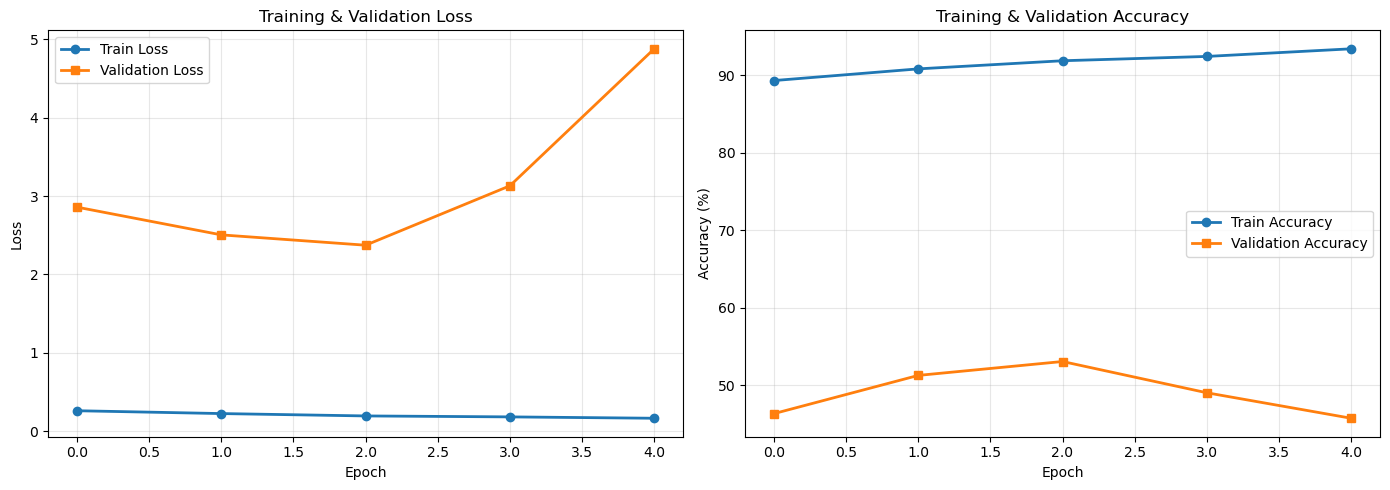

In [21]:
# ============================================
# 7. PLOT TRAINING RESULTS
# ============================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Loss plot
ax1.plot(train_losses, label='Train Loss', marker='o', linewidth=2)
ax1.plot(val_losses, label='Validation Loss', marker='s', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)


# Accuracy plot
ax2.plot(train_accuracies, label='Train Accuracy', marker='o', linewidth=2)
ax2.plot(val_accuracies, label='Validation Accuracy', marker='s', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training & Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_plots.png'))
plt.show()

In [22]:
print(f"📊 Training plots saved to: {SAVE_DIR}/training_plots.png")


📊 Training plots saved to: glaucoma_models/training_plots.png


In [ ]:
print("\n" + "="*60)
print("📊 FINAL MODEL EVALUATION")
print("="*60)

# Load best model
best_model_path = os.path.join(SAVE_DIR, 'best_glaucoma_model.pth')
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()




📊 FINAL MODEL EVALUATION


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [24]:
# Evaluate
correct = 0
total = 0
all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total
print(f"\n🎯 Test Accuracy: {test_accuracy:.2f}%")

# Calculate per-class accuracy
print(f"\n📋 Detailed Classification Report:")
print(classification_report(all_labels, all_predictions, target_names=class_names))


🎯 Test Accuracy: 53.06%

📋 Detailed Classification Report:
              precision    recall  f1-score   support

    glaucoma       0.43      0.95      0.59       241
      normal       0.92      0.29      0.44       428

    accuracy                           0.53       669
   macro avg       0.68      0.62      0.52       669
weighted avg       0.74      0.53      0.50       669



In [31]:
print("\n" + "="*60)
print("📱 EXPORTING MODEL FOR MOBILE APP")
print("="*60)

def export_for_mobile(model, class_names, save_dir, test_accuracy):
    """
    Export model in formats suitable for mobile apps
    """
    
    # Set model to evaluation mode
    model.eval()
    model.to('cpu')
    
    # Create wrapper with softmax for probability output
    class MobileModel(nn.Module):
        def __init__(self, model, class_names):
            super().__init__()
            self.model = model
            self.class_names = class_names
            
        def forward(self, x):
            x = self.model(x)
            return torch.softmax(x, dim=1)
    
    mobile_model = MobileModel(model, class_names)
    mobile_model.eval()
    
    # Trace the model with a dummy input
    example_input = torch.randn(1, 3, 224, 224)
    traced_model = torch.jit.trace(mobile_model, example_input)
    
    # Save PyTorch Mobile model
    mobile_path = os.path.join(save_dir, 'glaucoma_mobile_model.pt')
    traced_model.save(mobile_path)
    print(f"✅ Mobile model saved: {mobile_path}")
    print(f"   File size: {os.path.getsize(mobile_path) / (1024*1024):.2f} MB")
    
    # Save model metadata
    metadata = {
        'model_name': 'Glaucoma Detection Model',
        'architecture': 'ResNet50',
        'input_shape': [224, 224, 3],
        'normalization': {
            'mean': [0.485, 0.456, 0.406],
            'std': [0.229, 0.224, 0.225]
        },
        'classes': class_names,
        'num_classes': len(class_names),
        'test_accuracy': test_accuracy,
        'output_type': 'probability',
        'recommended_threshold': 0.7
    }
    
    metadata_path = os.path.join(save_dir, 'model_metadata.json')
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f"✅ Metadata saved: {metadata_path}")
    
    return mobile_path
export_for_mobile(model, class_names, SAVE_DIR, test_accuracy)



📱 EXPORTING MODEL FOR MOBILE APP
✅ Mobile model saved: glaucoma_models\glaucoma_mobile_model.pt
   File size: 94.27 MB
✅ Metadata saved: glaucoma_models\model_metadata.json


'glaucoma_models\\glaucoma_mobile_model.pt'